# 미니프로젝트: 머신러닝 프로세스 (Vibe Coding)

#### <목표>
오늘 배운 머신러닝 프로세스를 **제조 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- AI4I 2020 Predictive Maintenance (예지 정비)
- 10,000개 제조 장비 운전 데이터

| 변수명 | 설명 |
|:---:|:---|
| Type | 제품 품질 등급 (L: Low, M: Medium, H: High) |
| Air temperature | 공기 온도 [K] |
| Process temperature | 공정 온도 [K] |
| Rotational speed | 회전 속도 [rpm] |
| Torque | 토크 [Nm] |
| Tool wear | 공구 마모 시간 [min] |
| Machine failure | 기계 고장 여부 (0: 정상, 1: 고장) |
| TWF, HDF, PWF, OSF, RNF | 고장 유형별 발생 여부 |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 회귀 | `Torque` | 운전 조건(온도, 회전속도, 공구마모 등)으로 토크 예측 |
| 분류 | `Machine failure` | 운전 조건으로 기계 고장 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day1_miniproject.csv` 파일을 사용하기
- 하나의 원본 데이터에서 태스크별로 데이터프레임을 분리하기
    - **회귀용 (Regression):** 타겟 = `Torque`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Tool wear
    - **분류용 (Classification):** 타겟 = `Machine failure`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Torque, Tool wear

**[과제]** 써니는 오늘부로 제조 설비 운전 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 불러오고, 회귀용/분류용 데이터셋을 각각 어떻게 구성해야 할지 AI와 상의해서 코드를 작성하세요.

In [1]:
import pandas as pd
import numpy as np

# 이후 EDA에서 바로 쓸 예정이면 함께 import
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset/day1_miniproject.csv")
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# 원본은 유지, 태스크별로 X/y만 정의

X_reg = df[["Type", "Air temperature", "Process temperature",
            "Rotational speed", "Tool wear"]]
y_reg = df["Torque"]

Regression = pd.concat([X_reg, y_reg], axis=1)

X_cla = df[["Type", "Air temperature", "Process temperature",
            "Rotational speed", "Torque", "Tool wear"]]
y_cla = df["Machine failure"]

Classification = pd.concat([X_cla, y_cla], axis=1)

In [ ]:
print("Regression:", Regression.shape)
print("Classification:", Classification.shape)


Regression: (10000, 6)
Classification: (10000, 7)


In [7]:
Regression.info()
Classification.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  str    
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Tool wear            10000 non-null  int64  
 5   Torque               10000 non-null  float64
dtypes: float64(3), int64(2), str(1)
memory usage: 468.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  str    
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float6

---
## 1) 데이터 탐색 (EDA)

### 1-1) Value 기반 탐색

**[과제]** 써니는 본격적인 분석에 앞서 데이터가 어떻게 생겼는지 먼저 파악하고 싶습니다. AI와 어떠한 데이터 정보를 확인하면 좋을지 상의해보고 관련 정보를 확인해보세요.

무엇을 확인하면 좋은가?
순서	확인 항목	목적
1
head() / tail()
컬럼·값 형태, 이상한 값이 있는지
2
shape
행·열 개수 (회귀/분류 동일한지)
3
info()
타입, 결측치 개수
4
describe()
수치형 분포·범위·이상치 후보
5
describe(include="object")
Type 같은 범주형 요약
6
value_counts()
Type, Machine failure 분포
7
isnull().sum()
결측치 재확인
8
nunique()
클래스 수, 범주 개수

태스크별로 특히 볼 것
공통
- 결측치가 있는지
- 수치형 범위가 물리적으로 말이 되는지 (온도, rpm, 토크 등)
- Type이 L/M/H 몇 종류인지
회귀 (Regression, 타겟 Torque)
- Torque의 min/max/mean — 분포가 한쪽으로 치우쳤는지
- 입력 변수와 타겟의 대략적 범위
분류 (Classification, 타겟 Machine failure)
- 클래스 불균형 — 0(정상) vs 1(고장) 비율
    → 이후 train_test_split(stratify=...) 여부에 영향
- 고장 비율이 매우 낮으면 accuracy만으로 평가하면 위험

In [10]:
# 수치형 요약
df.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
# 범주형 요약 (Type)
df.describe(include="object")
df["Type"].value_counts()

C:\Users\Admin\AppData\Local\Temp\ipykernel_25952\3031864705.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [12]:
# 결측치
df.isnull().sum()

Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

In [13]:
# 고장 관련 (원본에서 한 번만 확인)
df["Machine failure"].value_counts()
df["Machine failure"].value_counts(normalize=True) * 100  # 비율(%)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

결측치가 없어 데이터 품질은 좋고, 분류 태스크에서 클래스 불균형이 가장 큰 이슈입니다.
즉, 희귀 사건(rare event) 예측 문제에 가깝습니다.

In [14]:
# ── 2) 회귀용 Regression ─────────────────────────────
print("=== Regression ===")
print("shape:", Regression.shape)
Regression.info()
Regression.describe()

=== Regression ===
shape: (10000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  str    
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Tool wear            10000 non-null  int64  
 5   Torque               10000 non-null  float64
dtypes: float64(3), int64(2), str(1)
memory usage: 468.9 KB


,Air temperature,Process temperature,Rotational speed,Tool wear,Torque
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,107.951000,39.986910
std,2.000259,1.483734,179.284096,63.654147,9.968934
min,295.300000,305.700000,1168.000000,0.000000,3.800000
25%,298.300000,308.800000,1423.000000,53.000000,33.200000
50%,300.100000,310.100000,1503.000000,108.000000,40.100000
75%,301.500000,311.100000,1612.000000,162.000000,46.800000
max,304.500000,313.800000,2886.000000,253.000000,76.600000


In [15]:
# 타겟 Torque만 따로
Regression["Torque"].describe()

count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: Torque, dtype: float64

In [16]:
# ── 3) 분류용 Classification ─────────────────────────
print("=== Classification ===")
print("shape:", Classification.shape)
Classification.info()
Classification.describe()

=== Classification ===
shape: (10000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  str    
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
dtypes: float64(3), int64(3), str(1)
memory usage: 547.0 KB


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [17]:
# 타겟 Machine failure 분포 (중요)
Classification["Machine failure"].value_counts()
Classification["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [18]:
# 입력 범주 Type
Classification["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

확인 후 메모해 두면 좋은 것
1. 결측치 — 있으면 2장 전처리에서 처리 방법 결정
2. Machine failure 비율 — 불균형이 크면 stratify, F1/AUC 등 지표 고려
3. Type — 범주 3개 → 나중에 원-핫 vs 라벨 인코딩 논의
4. 수치 범위 — 스케일 차이 큼 → 2장에서 StandardScaler 등 검토
5. 행 수 — 회귀·분류가 같은 10,000행인지 (shape로 확인)
---
결측치는 없으며, Machine failure는 3.39%로 심한 불균형이므로 stratified split과 Accuracy 외 지표(F1, Recall, AUC 등)를 사용해야 한다.

### 1-2) Graph 기반 탐색

#### 1-2-1) 단일 변수 분포

**[과제]** 써니는 변수들의 분포가 어떤 모양인지 한눈에 살펴보고 싶습니다. 여러 수치형 변수를 효율적으로 한 번에 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

A. 변수가 5~6개 수준이라 한 figure에 subplot으로 묶는 방식이 가장 효율적입니다. hist()로 먼저 훑고, 보고용은 seaborn subplot 버전 사용

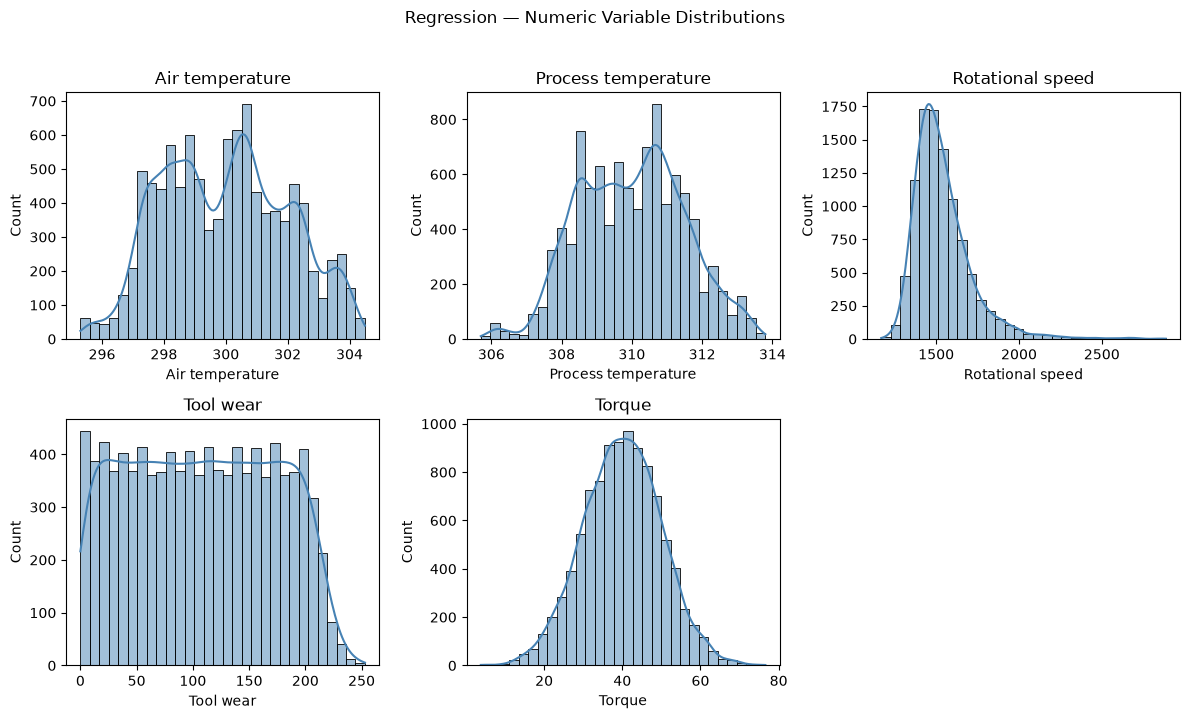

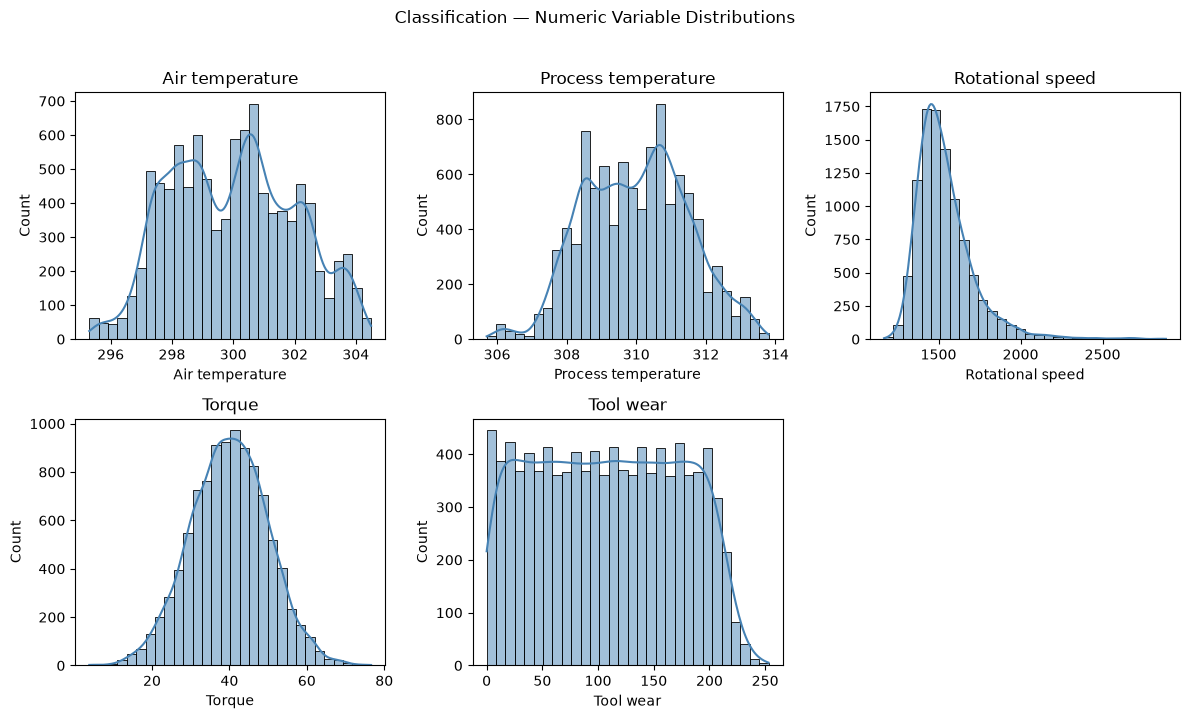

In [19]:
def plot_numeric_distributions(df, title, bins=30):
    """
    수치형 변수 분포를 subplot으로 한 번에 시각화
  - Type(문자열), Machine failure(0/1 타겟)은 자동 제외
    """
    num_cols = df.select_dtypes(include="number").columns.tolist()

    # 분류 데이터면 이진 타겟은 분포 히스토그램에서 제외
    if "Machine failure" in num_cols:
        num_cols.remove("Machine failure")

    n_cols = 3
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)  # 1차원으로 펼치기

    for ax, col in zip(axes, num_cols):
        sns.histplot(data=df, x=col, bins=bins, kde=True, ax=ax, color="steelblue")
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    # 남는 빈 subplot 숨기기
    for ax in axes[len(num_cols):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_numeric_distributions(Regression, "Regression — Numeric Variable Distributions")
plot_numeric_distributions(Classification, "Classification — Numeric Variable Distributions")

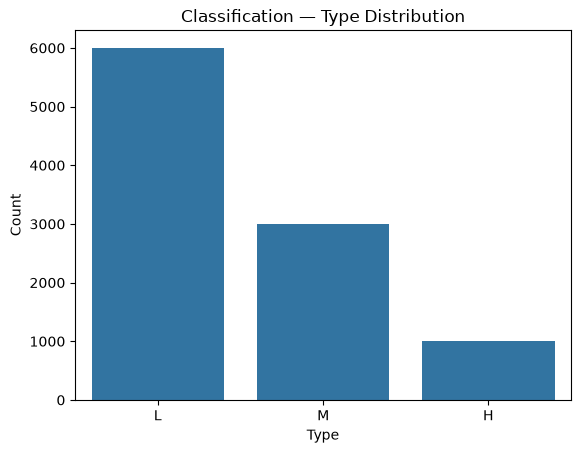

In [20]:
# Type은 문자열이라 histogram 대상이 아닙니다.
sns.countplot(data=Classification, x="Type", order=["L", "M", "H"])
plt.title("Classification — Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Q. 입력변수들을 종속변수에 따라 다른 색깔로 구분해서 보고싶습니다. 그래프를 그릴 수 있게 코드 작성해주세요.
A. 분류는 hue=Machine failure로 바로 그릴 수 있고, 회귀는 타겟 Torque가 연속값이라 구간으로 나눈 뒤 색을 구분하는 방식이 좋습니다.

In [ ]:
# 1) 공통 함수 - 수치형 입력 변수

def plot_features_by_target(df, target_col, title, bins=30, hue_labels=None):
    """
    수치형 입력 변수를 종속변수(target_col)별 색으로 구분해 histogram

    Parameters
    ----------
    df : DataFrame
    target_col : str
        종속변수 컬럼명 (예: 'Machine failure', 'Torque_bin')
    title : str
        그래프 제목
    bins : int
        histogram bin 개수
    hue_labels : list or None
        hue 범례 라벨 (예: ['Normal', 'Failure'])
    """
    num_cols = df.select_dtypes(include="number").columns.tolist()

    # 타겟·파생 타겟 컬럼은 입력에서 제외
    exclude = {target_col, "Torque"}  # 분류에서 Torque는 입력이므로 제외하지 않음
    if target_col == "Torque_bin":
        exclude = {"Torque_bin", "Torque"}
    if target_col == "Machine failure":
        exclude = {"Machine failure"}

    feature_cols = [c for c in num_cols if c not in exclude]

    n_cols = 3
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.8 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, feature_cols):
        sns.histplot(
            data=df,
            x=col,
            hue=target_col,
            bins=bins,
            kde=True,
            ax=ax,
            alpha=0.5,
            multiple="layer"   # 분포 겹쳐서 비교
        )
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    for ax in axes[len(feature_cols):]:
        ax.axis("off")

    if hue_labels is not None:
        handles, _ = axes[0].get_legend_handles_labels()
        fig.legend(handles, hue_labels, loc="upper right")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

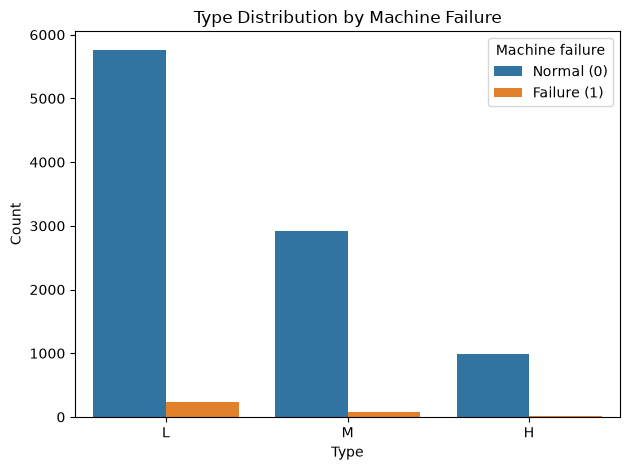

C:\Users\Admin\AppData\Local\Temp\ipykernel_25952\133388054.py:55: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  fig.legend(handles, hue_labels, loc="upper right")


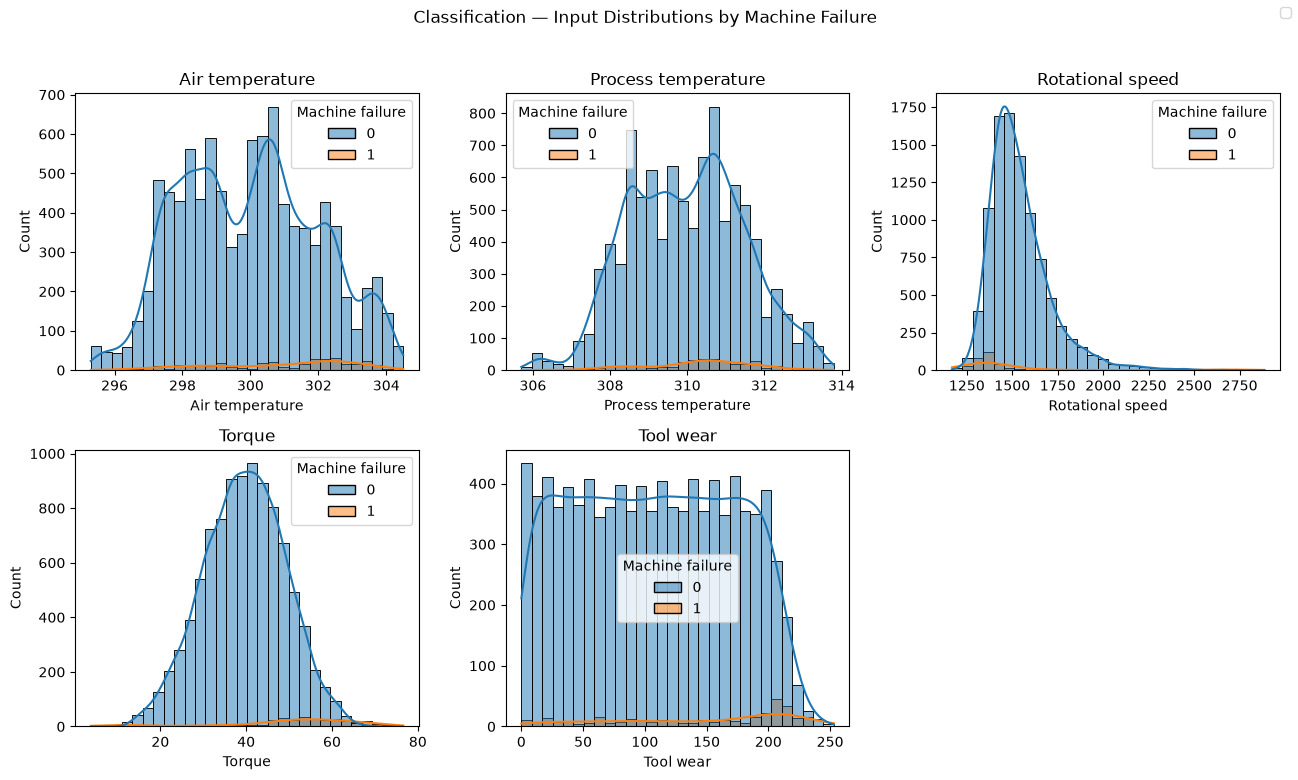

In [22]:
# 2) 분류 — Machine failure 기준 (0/1)

# 범주형 Type
sns.countplot(
    data=Classification,
    x="Type",
    hue="Machine failure",
    order=["L", "M", "H"]
)
plt.title("Type Distribution by Machine Failure")
plt.xlabel("Type")
plt.ylabel("Count")
plt.legend(title="Machine failure", labels=["Normal (0)", "Failure (1)"])
plt.tight_layout()
plt.show()

# 수치형 입력 변수 — 고장 여부별 색 구분
plot_features_by_target(
    Classification,
    target_col="Machine failure",
    title="Classification — Input Distributions by Machine Failure",
    hue_labels=["Normal (0)", "Failure (1)"]
)

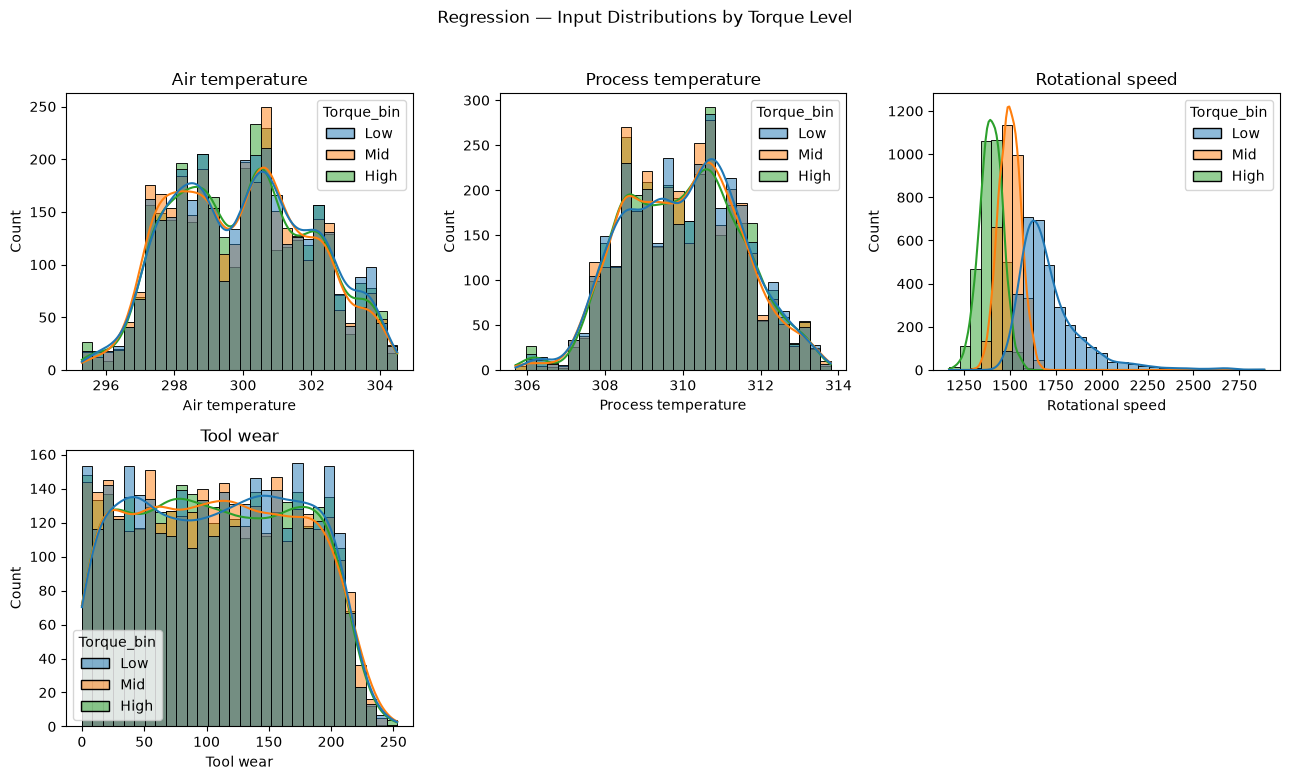

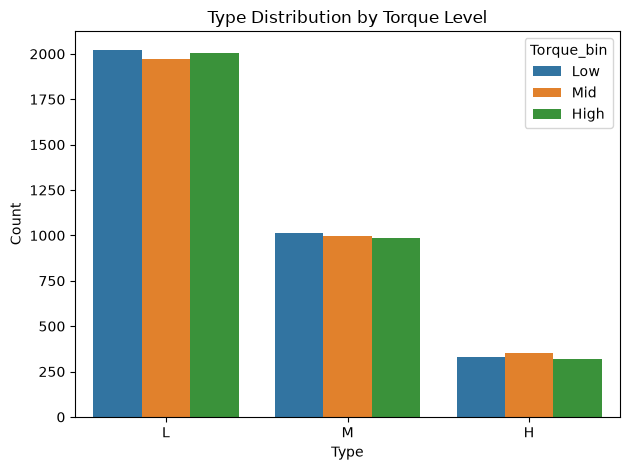

In [25]:
# 3) 회귀 — Torque 기준 (연속값 → 구간화)
# Torque는 연속값이라 hue에 쓰려면 구간을 나눕니다.

Regression_hue = Regression.copy()

# Torque를 낮음/중간/높음 3구간으로 분할
Regression_hue["Torque_bin"] = pd.qcut(
    Regression_hue["Torque"],
    q=3,
    labels=["Low", "Mid", "High"]
)

# 수치형 입력 변수 — Torque 구간별 색 구분
plot_features_by_target(
    Regression_hue,
    target_col="Torque_bin",
    title="Regression — Input Distributions by Torque Level"
)

# Type은 범주형이므로
sns.countplot(
    data=Regression_hue,
    x="Type",
    hue="Torque_bin",
    order=["L", "M", "H"]
)
plt.title("Type Distribution by Torque Level")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

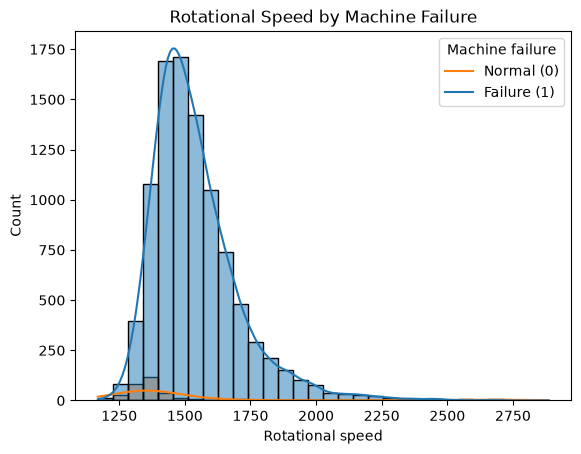

In [ ]:
# 4) 변수 하나씩 보고 싶을때 (간단 버전)

# 분류 예시: Rotational speed
sns.histplot(
    data=Classification,
    x="Rotational speed",
    hue="Machine failure",
    bins=30,
    kde=True,
    alpha=0.5,
    multiple="layer"
)
plt.title("Rotational Speed by Machine Failure")
plt.xlabel("Rotational speed")
plt.ylabel("Count")
plt.legend(title="Machine failure", labels=["Normal (0)", "Failure (1)"])
plt.show()

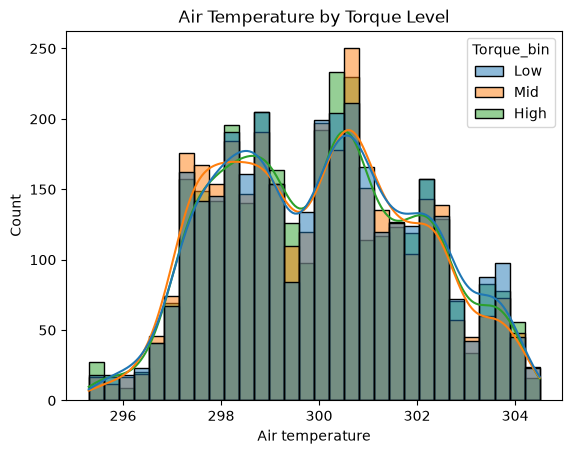

In [27]:
# 회귀 예시: Air temperature
sns.histplot(
    data=Regression_hue,
    x="Air temperature",
    hue="Torque_bin",
    bins=30,
    kde=True,
    alpha=0.5,
    multiple="layer"
)
plt.title("Air Temperature by Torque Level")
plt.xlabel("Air temperature")
plt.ylabel("Count")
plt.show()

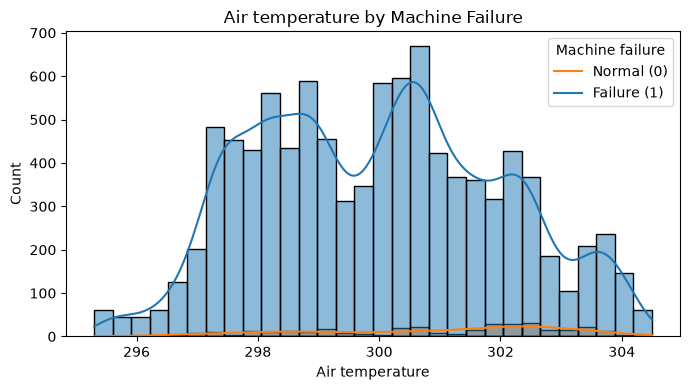

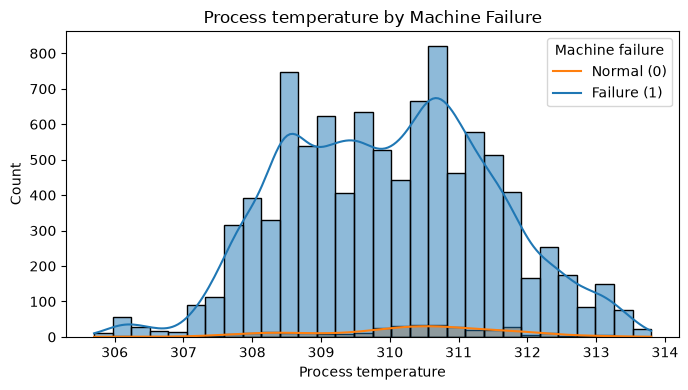

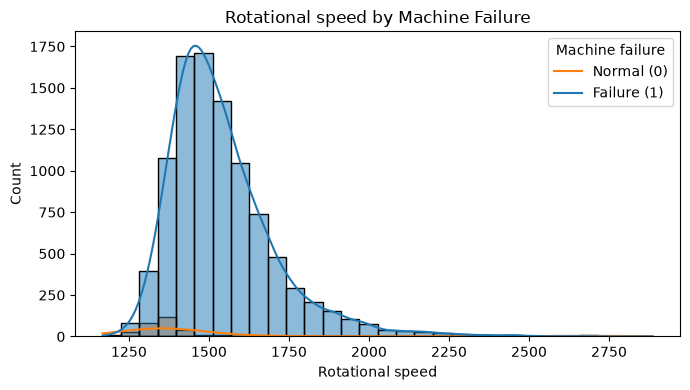

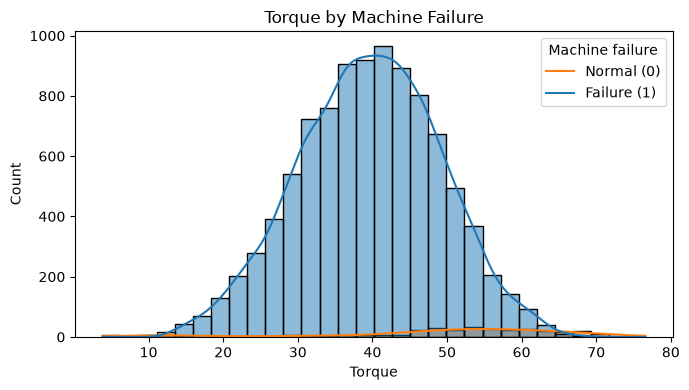

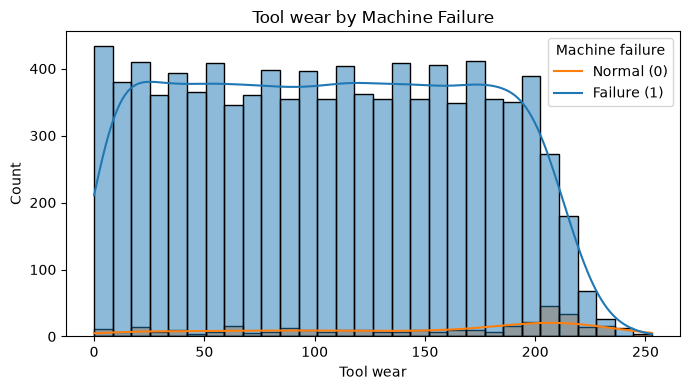

In [28]:
# 분류 - Machine failure 기준

# 수치형 입력 변수 목록 (타겟 제외)
cla_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
]

for col in cla_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=Classification,
        x=col,
        hue="Machine failure",
        bins=30,
        kde=True,
        alpha=0.5,
        multiple="layer"
    )
    plt.title(f"{col} by Machine Failure")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Machine failure", labels=["Normal (0)", "Failure (1)"])
    plt.tight_layout()
    plt.show()

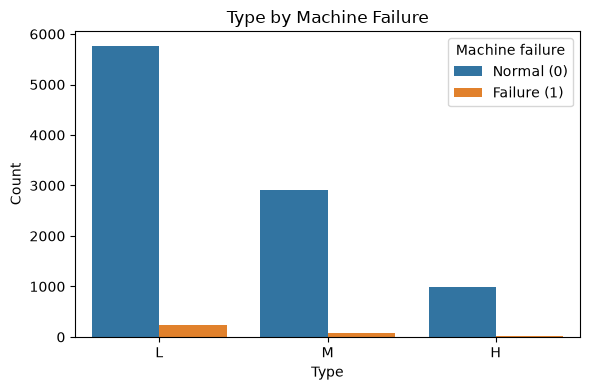

In [29]:
# 범주형 Type
plt.figure(figsize=(6, 4))
sns.countplot(
    data=Classification,
    x="Type",
    hue="Machine failure",
    order=["L", "M", "H"]
)
plt.title("Type by Machine Failure")
plt.xlabel("Type")
plt.ylabel("Count")
plt.legend(title="Machine failure", labels=["Normal (0)", "Failure (1)"])
plt.tight_layout()
plt.show()

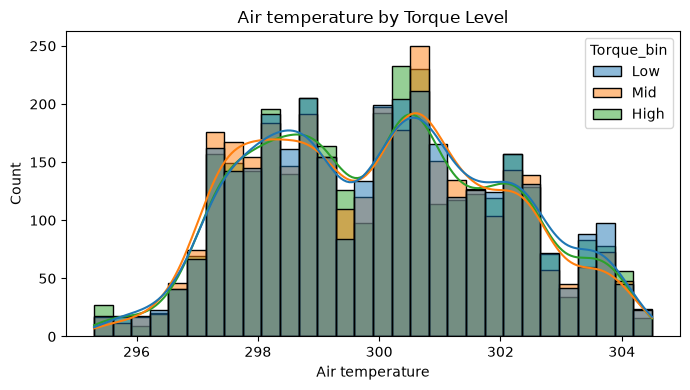

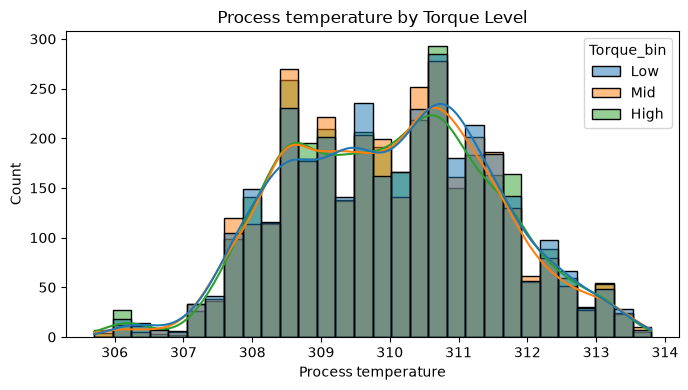

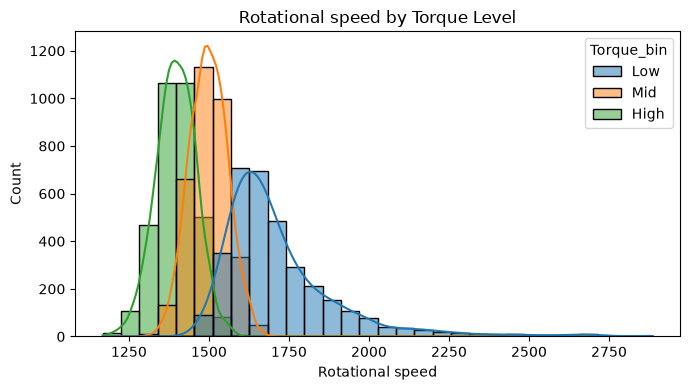

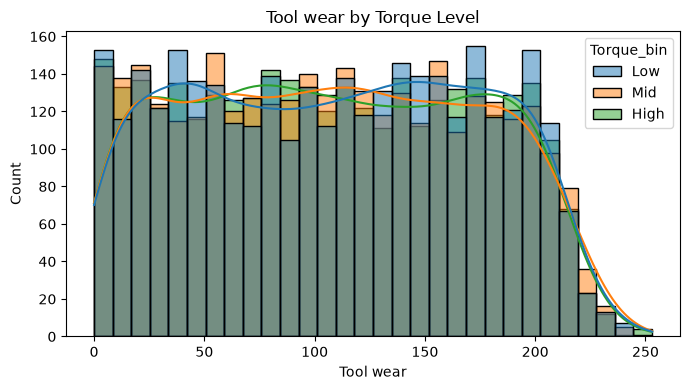

In [30]:
# 회귀 - Torque 구간 기준

Regression_hue = Regression.copy()
Regression_hue["Torque_bin"] = pd.qcut(
    Regression_hue["Torque"],
    q=3,
    labels=["Low", "Mid", "High"]
)

reg_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Tool wear",
]

for col in reg_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=Regression_hue,
        x=col,
        hue="Torque_bin",
        bins=30,
        kde=True,
        alpha=0.5,
        multiple="layer"
    )
    plt.title(f"{col} by Torque Level")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

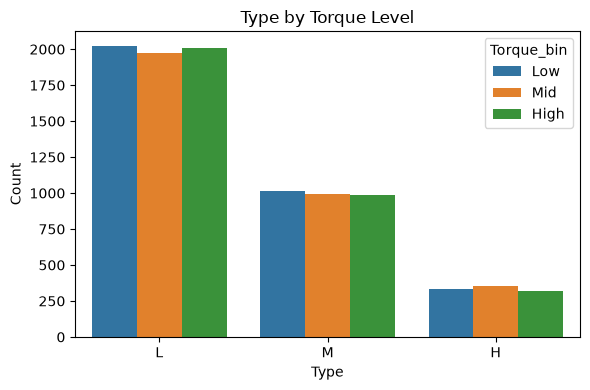

In [31]:
# 범주형 Type
plt.figure(figsize=(6, 4))
sns.countplot(
    data=Regression_hue,
    x="Type",
    hue="Torque_bin",
    order=["L", "M", "H"]
)
plt.title("Type by Torque Level")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**[과제]** 써니는 설비 고장이 실제로 얼마나 자주 발생하는지 궁금합니다. 고장 발생 빈도를 확인할 수 있는 방법을 AI와 함께 찾아보고, 그 결과를 시각화하거나 분석해 보세요. 이 결과가 앞으로의 분석(데이터 분할, 성능 평가 등)에 어떤 영향을 줄 수 있을지도 함께 생각해 보세요.

**[과제]** 써니는 설비가 고장 났을 때와 정상일 때 변수들의 분포가 어떻게 다른지 비교하고 싶습니다. 어떻게 비교하면 차이가 잘 드러날지 AI와 상의해서 방법을 정하고 직접 시각화해 보세요.

#### 1-2-2) 변수 간 관계

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. 전체 변수 간 관계를 효율적으로 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

**[과제]** 써니는 히트맵으로 상관관계가 높은 변수쌍은 찾았지만, 단순한 상관계수만으로 변수들이 서로 얽혀 있는 정도를 다 설명할 수 있을지 의문이 듭니다. 상관계수 외에 변수 간의 강한 관계를 파악할 수 있는 다른 방법이 있는지 AI와 함께 찾아보고, 직접 적용해 보세요.

---
## 2) 데이터 전처리

### 2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 모델에 넣기 전에 분석에 도움이 안 되거나, 오히려 결과를 왜곡시킬 수 있는 변수가 있는지 점검하려고 합니다. 어떤 변수를 빼야 하는지, 그 이유는 무엇인지 AI와 상의해서 정리하고 제거해 보세요.

### 2-2) 데이터 분할

**[과제]** 써니는 학습/테스트 데이터를 나누려고 합니다. 회귀용과 분류용 각각에 어떤 분할 방법과 기준이 적합할지 AI와 상의해서 정하고, 그 기준대로 직접 나눠 보세요.

### 2-3) 변수 스케일링

**[과제]** 써니는 수치형 변수들의 스케일이 제각각이라 모델 학습 전에 맞춰주고 싶습니다. 변수들의 분포를 보면서 어떤 스케일링 기법이 적합할지 AI와 상의해서 정하고 적용해 보세요.

**[과제]** 써니는 `Type` 변수를 모델에 넣으려면 숫자로 바꿔야 한다는 건 알고 있지만, 원-핫 인코딩과 라벨 인코딩 중 어느 쪽이 맞을지 고민입니다. 어떤 기준으로 선택해야 할지 AI와 상의해서 정하고 적용해 보세요.

---
## 3) 모델링

### 3-1) 모델 생성 및 학습

**[과제]** 써니는 여러 모델의 성능을 한 번에 비교해보고 싶습니다. 회귀와 분류 각각 어떤 모델을 후보로 둘지, 매번 코드를 새로 짜지 않고 효율적으로 비교할 방법은 무엇일지 AI와 상의해서 코드를 작성해 보세요.

### 3-2) 테스트 데이터 예측

**[과제]** 써니는 앞서 학습시킨 회귀 및 분류 모델들로 테스트 데이터에 대한 예측을 수행하려고 합니다. 모든 모델의 예측 결과를 한 번에 뽑을 수 있도록 AI와 함께 코드를 작성해 보세요.

### 3-3) 성능 평가

**[과제]** 써니는 모델 성능을 비교하려고 하는데, 회귀와 분류 각각 사용할 수 있는 지표가 다양해서 무엇을 기준으로 봐야 할지 고민입니다. 적절한 지표를 AI와 상의해서 정하고, 그 기준으로 가장 좋은 모델을 선택해 보세요.

---
## 4) 모델 고도화

**[과제]** 써니는 가장 성능이 좋았던 모델을 더 끌어올리고 싶습니다. 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 AI와 상의해서 정하고, 그 기준으로 성능을 높여 보세요.

---
## 5) 모델 결과 분석

**[과제]** 써니는 최종적으로 어떤 운전 조건이 토크와 고장에 가장 큰 영향을 미치는지 정리해서 보고하려고 합니다. 회귀와 분류 각각에서 성능이 가장 좋았던 모델의 변수 중요도를 구하고 시각화하는 방법을 AI와 함께 알아본 뒤, 그 결과로부터 인사이트를 도출해 보세요.